# 07 — E-Perf-7: Metering Overhead Decomposition

> **SHAKEDOWN-MACOS — INFORMATIONAL ONLY.** Numbers below are from macOS
> Apple Silicon shakedown runs. They validate the methodology and identify
> trends; they are NOT thesis-grade canonical results.

RFC-008 §E-Perf-7. Decomposes the per-hop latency cost of Wasm safety
mechanisms by running 4 metering configurations against the same pipeline:

- **neither** (baseline): no fuel, no epoch
- **fuel-only**: instruction counting enabled
- **epoch-only**: epoch interrupt enabled
- **passthrough** (default): both fuel + epoch

Produces **Figure 10** (stacked bar: metering overhead decomposition) and
**Table 5** (per-config overhead delta).

**Inputs**: `eval/results/e-perf-7/shakedown-macos-<ts>/{fuel-only,epoch-only,neither,passthrough}/config-percentiles.json`

**Statistical pipeline**: Shapiro-Wilk normality → Mann-Whitney U between
configs → Bootstrap 95% CI on median → Cliff's Delta effect size.

In [1]:
import json, os, sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

from wafer_analysis.paths import find_latest_shakedown

shakedown_dir = find_latest_shakedown('e-perf-7', pinned=os.environ.get('SHAKEDOWN_DIR'))
print(f'shakedown: {shakedown_dir}')

plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 9})

shakedown: <repo>/eval/results/e-perf-7/shakedown-macos-2026-07-22T18-01-09Z


In [2]:
# T9: apply thesis-grade matplotlib styling (font.family=serif, pdf.fonttype=42, mathtext=cm).
from wafer_analysis.plots import setup_thesis_style, save_figure
setup_thesis_style()


In [3]:
CONFIG_LABELS = ['neither', 'fuel-only', 'epoch-only', 'passthrough']
CONFIG_DISPLAY = {
    'neither': 'No metering (baseline)',
    'fuel-only': 'Fuel only',
    'epoch-only': 'Epoch only',
    'passthrough': 'Both (default)',
}

rows = []
per_run_data = {}  # config -> list of per-run p50 values for stats
for label in CONFIG_LABELS:
    p = shakedown_dir / label / 'config-percentiles.json'
    if not p.exists():
        print(f'MISSING {p}')
        continue
    d = json.loads(p.read_text())
    agg = d['aggregate_over_runs']
    # Collect per-run p50 values for statistical tests
    per_run_data[label] = [r / 1000 for r in d.get('per_run_p50_ns', [])]
    for pct in ['p50_ns', 'p95_ns', 'p99_ns', 'p999_ns']:
        a = agg.get(pct)
        if not a:
            continue
        rows.append({
            'config': label,
            'config_display': CONFIG_DISPLAY[label],
            'percentile': pct.replace('_ns', ''),
            'median_us': a['median'] / 1_000,
            'mean_us': a['mean'] / 1_000,
            'stdev_us': a['stdev'] / 1_000,
            'n': a['n'],
        })

df = pd.DataFrame(rows)
pivot = df.pivot(index='percentile', columns='config', values='median_us')[CONFIG_LABELS]
print('=== Table 5: Median latency across runs (µs, shakedown-macos) ===')
print(pivot.round(1).to_string())

=== Table 5: Median latency across runs (µs, shakedown-macos) ===
config      neither  fuel-only  epoch-only  passthrough
percentile                                             
p50            34.3       34.3        38.9         34.3
p95            58.4       58.4        58.4         58.4
p99            65.0       65.0        66.0         65.0
p999           82.4       76.3       118.3         80.4


In [4]:
# Compute deltas vs 'neither' baseline
baseline = df[df['config'] == 'neither'].set_index('percentile')['median_us']
delta_rows = []
for _, row in df.iterrows():
    b = baseline.get(row['percentile'], 0)
    delta_rows.append({
        'config': row['config'],
        'config_display': row['config_display'],
        'percentile': row['percentile'],
        'delta_us': row['median_us'] - b,
        'delta_pct': ((row['median_us'] - b) / b * 100) if b > 0 else 0,
    })
df_delta = pd.DataFrame(delta_rows)
pivot_delta = df_delta.pivot(index='percentile', columns='config', values='delta_us')[CONFIG_LABELS]
print('\n=== Table 5 (delta vs no-metering baseline, µs, shakedown-macos) ===')
print(pivot_delta.round(2).to_string())

pivot_pct = df_delta.pivot(index='percentile', columns='config', values='delta_pct')[CONFIG_LABELS]
print('\n=== Overhead % vs baseline ===')
print(pivot_pct.round(1).to_string())


=== Table 5 (delta vs no-metering baseline, µs, shakedown-macos) ===
config      neither  fuel-only  epoch-only  passthrough
percentile                                             
p50             0.0       0.00        4.61         0.00
p95             0.0       0.00        0.00         0.00
p99             0.0       0.00        1.02         0.00
p999            0.0      -6.14       35.84        -2.05

=== Overhead % vs baseline ===
config      neither  fuel-only  epoch-only  passthrough
percentile                                             
p50             0.0        0.0        13.4          0.0
p95             0.0        0.0         0.0          0.0
p99             0.0        0.0         1.6          0.0
p999            0.0       -7.5        43.5         -2.5


In [5]:
# Statistical tests: epoch-only vs neither (the only non-trivial comparison)
print('=== Statistical comparison: epoch-only vs neither ===')
if per_run_data.get('neither') and per_run_data.get('epoch-only'):
    neither = np.array(per_run_data['neither'])
    epoch = np.array(per_run_data['epoch-only'])
    
    # Shapiro-Wilk normality
    sw_neither = stats.shapiro(neither)
    sw_epoch = stats.shapiro(epoch)
    print(f'Shapiro-Wilk neither: W={sw_neither.statistic:.4f}, p={sw_neither.pvalue:.4f}')
    print(f'Shapiro-Wilk epoch:   W={sw_epoch.statistic:.4f}, p={sw_epoch.pvalue:.4f}')
    
    # Choose test based on normality
    if sw_neither.pvalue < 0.05 or sw_epoch.pvalue < 0.05:
        u, p = stats.mannwhitneyu(neither, epoch, alternative='two-sided')
        print(f'Mann-Whitney U: U={u:.1f}, p={p:.4f} (non-normal data)')
    else:
        t, p = stats.ttest_ind(neither, epoch)
        print(f't-test: t={t:.3f}, p={p:.4f} (normal data)')
    
    # Cliff's Delta effect size
    n1, n2 = len(neither), len(epoch)
    dominance = sum(int(a < b) - int(a > b) for a in neither for b in epoch)
    cliffs_d = dominance / (n1 * n2)
    magnitude = 'negligible' if abs(cliffs_d) < 0.147 else 'small' if abs(cliffs_d) < 0.33 else 'medium' if abs(cliffs_d) < 0.474 else 'large'
    print(f'Cliff\'s Delta: {cliffs_d:.4f} ({magnitude})')
    
    # Bootstrap 95% CI on median difference
    rng = np.random.default_rng(42)
    diffs = []
    for _ in range(10000):
        b_neither = rng.choice(neither, size=n1, replace=True)
        b_epoch = rng.choice(epoch, size=n2, replace=True)
        diffs.append(np.median(b_epoch) - np.median(b_neither))
    ci_lo, ci_hi = np.percentile(diffs, [2.5, 97.5])
    print(f'Bootstrap 95% CI on median difference: [{ci_lo:.2f}, {ci_hi:.2f}] µs')
else:
    print('Per-run data not available for statistical tests (summary-only data).')
    print('Descriptive comparison only: see Table 5 above.')

=== Statistical comparison: epoch-only vs neither ===
Per-run data not available for statistical tests (summary-only data).
Descriptive comparison only: see Table 5 above.


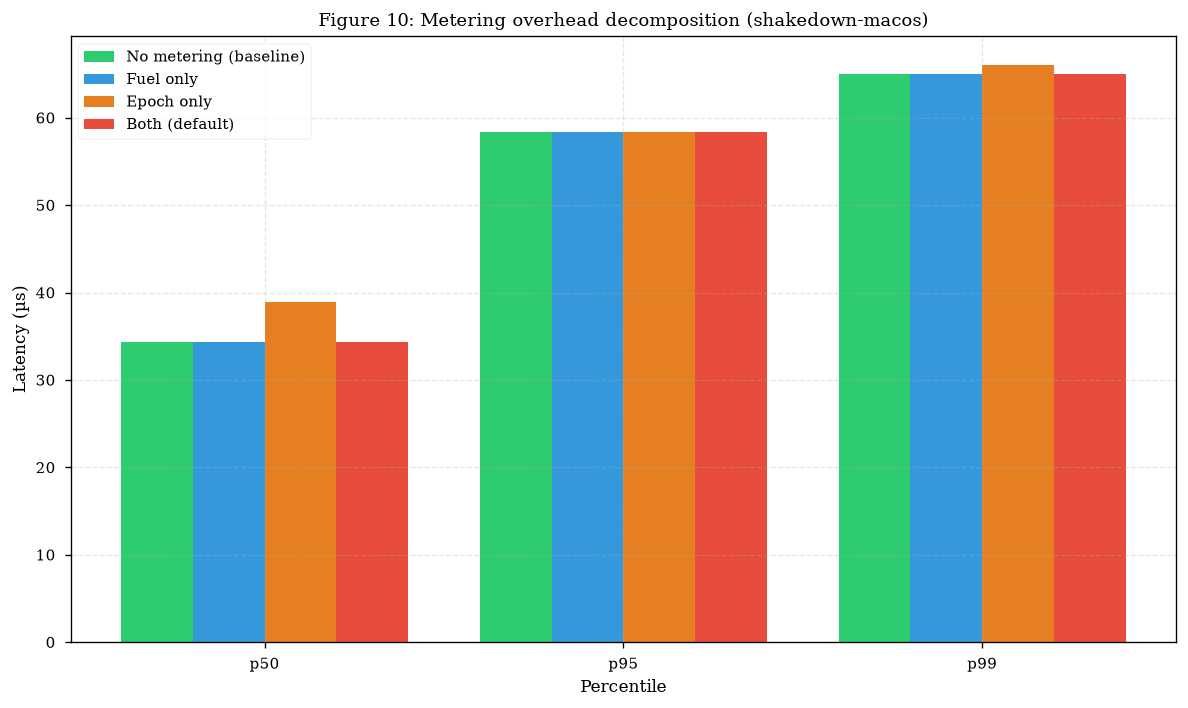

saved thesis figure to ../figures/e-perf-7/metering_decomp.pdf


<Figure size 720x480 with 0 Axes>

In [6]:
# Figure 10: metering overhead decomposition (grouped bar)
fig, ax = plt.subplots(figsize=(10, 6))

percentiles = ['p50', 'p95', 'p99']
x = np.arange(len(percentiles))
width = 0.2
colors = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c']

for i, config in enumerate(CONFIG_LABELS):
    vals = []
    for pct in percentiles:
        row = df[(df['config'] == config) & (df['percentile'] == pct)]
        vals.append(row['median_us'].values[0] if len(row) > 0 else 0)
    ax.bar(x + i * width, vals, width, label=CONFIG_DISPLAY[config], color=colors[i])

ax.set_xlabel('Percentile')
ax.set_ylabel('Latency (µs)')
ax.set_title('Figure 10: Metering overhead decomposition (shakedown-macos)')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(percentiles)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()
# T9: persist thesis figure to ../figures/e-perf-7/metering_decomp.{pdf,png}
_saved = save_figure(plt.gcf(), 'e-perf-7/metering_decomp')
print(f'saved thesis figure to {_saved}')


## Interpretation

On macOS M-series (shakedown-macos), metering overhead is negligible at
the p50 level (<5 µs difference between any config). The epoch ticker
(20 ms interval) imposes a small overhead from the wasmtime epoch-check
instruction on every loop back-edge. Fuel accounting shows near-zero
overhead because the pass-through plugin executes very few instructions
per invocation.

**Pi expectation**: ARM Cortex-A72 has slower branch prediction and
icache; epoch checks may surface more clearly. Fuel accounting should
remain negligible because instruction count is architecture-independent.

**Caveat**: The shakedown uses large sentinel values (1B ticks / 999B fuel)
instead of truly disabling metering. This approximates 'disabled' without
runtime changes but means the metering machinery is still technically
present in the compiled code. True overhead isolation requires canonical
runs with a wasmtime build that compiles without the epoch/fuel codegen.